# MDC Anomaly Detection -- Model v3

Loads `windows_v3.npz` from `mdc_preprocess_v3.ipynb` (T=25 windows, 6.25 min coverage).

**Improvements over v2:**

| Component | v2 | v3 |
|---|---|---|
| Bottleneck | 32 | **16** (tighter compression) |
| Feed-forward | 128 | **192** (3x d_model, correct ratio) |
| Loss function | MSE | **Huber** (robust to benign outliers) |
| Early stopping | val benign MSE only | **MSE + ROC-AUC** (every 5 epochs) |
| Anomaly scoring | Equal feature weights | **Per-feature variance weighting** |
| Thresholds | Youden J, p95/p99, F1, precision | + **Z-score (2.5σ, 3σ)** + **F-beta (0.5, 2.0)** |
| Decoder target | input-derived (v2 bug fixed) | **Learned pos_queries** (no leakage) |
| Noise std | 0.05 | **0.05** (conservative, bottleneck now enforces compression) |

## 0. Environment

In [ ]:
import sys, subprocess

try:
    import google.colab
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'torch', 'scikit-learn', 'matplotlib', 'optuna'],
        check=False,
    )

print(f'Running in Colab: {_IN_COLAB}')

Running in Colab: True


## 1. Configuration

In [ ]:
from __future__ import annotations
import json, os, random, gc
from pathlib import Path
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Training
BATCH_SIZE   = 32
MAX_EPOCHS   = 100
PATIENCE     = 20
LR           = 5e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.15
GRAD_CLIP    = 1.0
HUBER_DELTA  = 1.0      # Huber loss delta -- reduces influence of benign outliers

# Architecture  (lightweight, post-analysis)
D_MODEL        = 64
N_HEAD         = 4
N_ENC_LAYERS   = 2
N_DEC_LAYERS   = 1
DIM_FF         = 192    # 3x d_model (fixed from 128 -- was inverted ratio)
BOTTLENECK_DIM = 16     # 4x compression of d_model (tighter than v2's 32)

# Denoising
USE_DENOISING = True
NOISE_STD     = 0.05    # conservative -- model now relies on bottleneck, not input bypass

# Scoring
SCORE_MEAN_W     = 0.7
SCORE_MAX_W      = 0.3
SCORE_BATCH_SIZE = 128
AUC_CHECK_FREQ   = 5    # compute ROC-AUC on val every N epochs for early stopping

# HPO
N_TRIALS      = 15
HPO_MAX_EPOCH = 30
HPO_PATIENCE  = 8

# Paths
if _IN_COLAB:
    RUN_DIR  = Path('/content/drive/MyDrive/Module4_MDC/runs/v3_run')
    DATA_DIR = Path('/content/drive/MyDrive/Module4_MDC/processed_v3')
else:
    RUN_DIR  = Path('../outputs/mdc_v3_run')
    DATA_DIR = Path('../data/processed')

print('Config loaded.')
print(f'  DATA_DIR       : {DATA_DIR}')
print(f'  Architecture   : D_MODEL={D_MODEL}  BOTTLENECK={BOTTLENECK_DIM}  DIM_FF={DIM_FF}')
print(f'                   N_ENC={N_ENC_LAYERS}  N_DEC={N_DEC_LAYERS}  N_HEAD={N_HEAD}')
print(f'  Training       : LR={LR}  BATCH={BATCH_SIZE}  MAX_EPOCHS={MAX_EPOCHS}')
print(f'  Loss           : Huber (delta={HUBER_DELTA})')
print(f'  AUC check freq : every {AUC_CHECK_FREQ} epochs')

Config loaded.
  DATA_DIR       : /content/drive/MyDrive/Module4_MDC/processed_v3
  Architecture   : D_MODEL=64  BOTTLENECK=16  DIM_FF=192
                   N_ENC=2  N_DEC=1  N_HEAD=4
  Training       : LR=0.0005  BATCH=32  MAX_EPOCHS=100
  Loss           : Huber (delta=1.0)
  AUC check freq : every 5 epochs


## 2. Mount Drive & Load `windows_v3.npz`

In [ ]:
import os, shutil, gc
from pathlib import Path
import numpy as np

if _IN_COLAB:
    from google.colab import drive
    _mount = '/content/drive'
    try:
        drive.flush_and_unmount()
    except Exception:
        pass
    if os.path.exists(_mount):
        shutil.rmtree(_mount)
    os.makedirs(_mount, exist_ok=True)
    drive.mount(_mount)

NPZ_PATH = DATA_DIR / 'windows_v3.npz'

if not NPZ_PATH.is_file() and _IN_COLAB:
    myd  = Path('/content/drive/MyDrive')
    hits = sorted(myd.rglob('windows_v3.npz'), key=lambda p: len(str(p)))
    if hits:
        NPZ_PATH = hits[0]
        print(f'Found at: {NPZ_PATH}')

if not NPZ_PATH.is_file():
    raise FileNotFoundError(
        'windows_v3.npz not found at ' + str(NPZ_PATH) + '. '
        'Run mdc_preprocess_v3.ipynb first.'
    )

z       = np.load(NPZ_PATH)
X_train = z['X_train'].astype(np.float32)
X_val   = z['X_val'].astype(np.float32)
X_test  = z['X_test'].astype(np.float32)
y_val   = z['y_val'].astype(np.int64)
y_test  = z['y_test'].astype(np.int64)
del z
gc.collect()

n_features = X_train.shape[2]
T          = X_train.shape[1]

print(f'Loaded   : {NPZ_PATH}')
print(f'X_train  : {X_train.shape}  (benign only)')
print(f'X_val    : {X_val.shape}   attack_rate={y_val.mean():.4f}')
print(f'X_test   : {X_test.shape}  attack_rate={y_test.mean():.4f}')
print(f'T={T}  n_features={n_features}')

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Loaded   : /content/drive/MyDrive/Module4_MDC/processed_v3/windows_v3.npz
X_train  : (4720, 25, 166)  (benign only)
X_val    : (3653, 25, 166)   attack_rate=0.7369
X_test   : (3654, 25, 166)  attack_rate=0.7367
T=25  n_features=166
Device: cpu


## 3. PyTorch Datasets & DataLoaders

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.from_numpy(X_train).float()
X_val_t   = torch.from_numpy(X_val).float()

train_loader = DataLoader(
    TensorDataset(X_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    pin_memory=False,
    num_workers=0,
)

del X_train   # free numpy array -- DataLoader reads from tensor only
gc.collect()

print(f'Train batches: {len(train_loader)}  |  Val: {len(X_val_t)}  |  Test: {len(X_test)}')

Train batches: 148  |  Val: 3653  |  Test: 3654


## 4. Scoring Functions

Defined **before model training** so `_eval_auc` can be used inside the training loop for ROC-AUC-based early stopping.

`compute_scores(X, feat_std=None)` — pass `feat_std` after training for variance-weighted scoring.
`_eval_auc(model, X_val_t, y_val)` — lightweight unweighted AUC for in-training monitoring.

In [ ]:
from sklearn.metrics import roc_auc_score as _roc_auc_score


@torch.no_grad()
def _eval_auc(m, X_val_t, y_val, device, batch_size=SCORE_BATCH_SIZE):
    """Quick unweighted ROC-AUC on val for early stopping (no feat_std needed)."""
    m.eval()
    scores = []
    for start in range(0, len(X_val_t), batch_size):
        xb    = X_val_t[start:start + batch_size].to(device)
        recon = m(xb)
        err   = (recon - xb).pow(2)
        scores.append(err.mean(dim=(1, 2)).cpu().numpy())
        del xb, recon, err
    try:
        return float(_roc_auc_score(y_val, np.concatenate(scores)))
    except Exception:
        return 0.5


@torch.no_grad()
def compute_scores(
    X,
    feat_std=None,
    batch_size=SCORE_BATCH_SIZE,
    mean_w=SCORE_MEAN_W,
    max_w=SCORE_MAX_W,
    _model=None,
):
    """
    Variance-weighted anomaly scoring.

    feat_std : (n_features,) per-feature reconstruction std from benign val.
               When provided, each feature's error is divided by its std so
               low-variance features (strong anomaly signal) contribute more.
               Pass None for unweighted scoring (e.g. during HPO).
    _model   : model to score with; defaults to global 'model'.
    """
    m = _model if _model is not None else model
    m.eval()
    scores = []
    for start in range(0, len(X), batch_size):
        xb    = torch.from_numpy(X[start:start + batch_size]).float().to(device)
        recon = m(xb)
        err   = (recon - xb).pow(2)           # (B, T, F)
        if feat_std is not None:
            w   = torch.from_numpy(feat_std).float().to(device)
            err = err / w[None, None, :]       # normalize by per-feature variance
            del w
        # mean_w * mean(all elements) + max_w * worst-timestep mean
        s_mean = err.mean(dim=(1, 2))          # (B,)
        s_max  = err.mean(dim=2).amax(dim=1)   # (B,) -- max over timesteps, mean over features
        scores.append((mean_w * s_mean + max_w * s_max).cpu().numpy())
        del xb, recon, err, s_mean, s_max
    gc.collect()
    return np.concatenate(scores)


print('Scoring functions defined.')
print('  compute_scores(X, feat_std=None)  -- pass feat_std for variance weighting')
print('  _eval_auc(model, X_val_t, y_val)  -- used during training for early stopping')

Scoring functions defined.
  compute_scores(X, feat_std=None)  -- pass feat_std for variance weighting
  _eval_auc(model, X_val_t, y_val)  -- used during training for early stopping


## 5. Model Architecture

**Key design decisions vs v2:**
- `BOTTLENECK_DIM=16`: 4× compression of d_model=64 — forces the model to discard attack-specific patterns that were never seen in benign training
- `DIM_FF=192`: corrects the v2 HPO choice of 64 (which was less than d_model — an inverted ratio)
- `pos_queries`: decoder target is learned per-position vectors, NOT derived from the input — reconstruction must come entirely from the bottleneck memory

In [ ]:
import torch
import torch.nn as nn
import math


class SinusoidalPE(nn.Module):
    """Sinusoidal positional encoding (batch_first=True)."""

    def __init__(self, d_model: int, max_len: int = 200, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class BottleneckTransformerAE(nn.Module):
    """
    Encoder -> temporal mean-pool -> bottleneck -> Decoder.

    Decoder uses learned position queries (NOT input-derived), so reconstruction
    must go through the bottleneck. Attacks score high because their compact
    representation differs from the benign manifold learned during training.
    """

    def __init__(
        self,
        n_features: int,
        d_model: int = 64,
        nhead: int = 4,
        num_enc_layers: int = 2,
        num_dec_layers: int = 1,
        dim_ff: int = 192,
        dropout: float = 0.15,
        bottleneck_dim: int = 16,
        max_len: int = 200,
    ):
        super().__init__()
        self.input_proj  = nn.Linear(n_features, d_model)
        self.pe          = SinusoidalPE(d_model, max_len=max_len, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)

        self.bn_down = nn.Sequential(
            nn.Linear(d_model, bottleneck_dim),
            nn.LayerNorm(bottleneck_dim),
            nn.GELU(),
        )
        self.bn_up = nn.Linear(bottleneck_dim, d_model)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)

        self.output_proj = nn.Linear(d_model, n_features)

        # Learned position queries -- NOT derived from input (no decoder leakage)
        self.pos_queries = nn.Parameter(torch.zeros(max_len, d_model))
        self.d_model      = d_model
        self.bottleneck_dim = bottleneck_dim

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h      = self.pe(self.input_proj(x))
        h      = self.encoder(h)
        pooled = h.mean(dim=1)
        return self.bn_down(pooled)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape

        # Encode -> bottleneck
        h      = self.pe(self.input_proj(x))
        h      = self.encoder(h)
        pooled = h.mean(dim=1)           # (B, d_model)  temporal mean-pool
        z      = self.bn_down(pooled)    # (B, bottleneck_dim)
        z_up   = self.bn_up(z)           # (B, d_model)

        # Memory: same bottleneck vector broadcast across T timesteps
        memory = z_up.unsqueeze(1).expand(-1, T, -1)   # (B, T, d_model)

        # Decode using learned position queries -- zero knowledge of input x
        tgt = self.pe(self.pos_queries[:T].unsqueeze(0).expand(B, -1, -1))
        out = self.decoder(tgt, memory)

        return self.output_proj(out)     # (B, T, n_features)


def build_model(
    n_features: int,
    d_model: int        = D_MODEL,
    nhead: int          = N_HEAD,
    num_enc_layers: int = N_ENC_LAYERS,
    num_dec_layers: int = N_DEC_LAYERS,
    dim_ff: int         = DIM_FF,
    dropout: float      = DROPOUT,
    bottleneck_dim: int = BOTTLENECK_DIM,
) -> BottleneckTransformerAE:
    return BottleneckTransformerAE(
        n_features=n_features,
        d_model=d_model, nhead=nhead,
        num_enc_layers=num_enc_layers,
        num_dec_layers=num_dec_layers,
        dim_ff=dim_ff, dropout=dropout,
        bottleneck_dim=bottleneck_dim,
        max_len=max(T + 10, 200),
    ).to(device)


model    = build_model(n_features)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: BottleneckTransformerAE')
print(f'  n_features={n_features}  T={T}')
print(f'  D_MODEL={D_MODEL}  BOTTLENECK_DIM={BOTTLENECK_DIM}  DIM_FF={DIM_FF}')
print(f'  Trainable parameters: {n_params:,}')

Model: BottleneckTransformerAE
  n_features=166  T=25
  D_MODEL=64  BOTTLENECK_DIM=16  DIM_FF=192
  Trainable parameters: 178,390


/tmp/ipykernel_2870/4276833471.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


## 6. Training with Huber Loss + Dual Early Stopping

**Huber loss** (`delta=1.0`): behaves as MSE for small errors, MAE for large errors.
Reduces influence of rare benign outliers during training, leading to a tighter benign score distribution and lower p95 benign score.

**Dual early stopping:**
- MSE-based: saves checkpoint when benign val MSE improves (standard criterion)
- AUC-based: every 5 epochs, computes ROC-AUC on full val; saves checkpoint when AUC improves
- At end: loads AUC checkpoint if it achieved > 0.55, otherwise loads MSE checkpoint

In [ ]:
import torch.nn.functional as F
from torch import optim
from sklearn.metrics import roc_auc_score


def add_noise(x: torch.Tensor, std: float) -> torch.Tensor:
    return x + torch.randn_like(x) * std


def train_model(
    model,
    train_loader,
    X_val_t,
    y_val,
    max_epochs: int    = MAX_EPOCHS,
    patience: int      = PATIENCE,
    lr: float          = LR,
    weight_decay: float = WEIGHT_DECAY,
    grad_clip: float   = GRAD_CLIP,
    use_denoising: bool = USE_DENOISING,
    noise_std: float   = NOISE_STD,
    huber_delta: float = HUBER_DELTA,
    auc_check_freq: int = AUC_CHECK_FREQ,
    verbose: bool      = True,
):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6,
    )

    xv_benign = X_val_t[y_val == 0].to(device)
    if len(xv_benign) == 0:
        xv_benign = X_val_t.to(device)

    def eval_benign_mse() -> float:
        model.eval()
        with torch.no_grad():
            return float(F.mse_loss(model(xv_benign), xv_benign).item())

    best_mse_state  = None
    best_auc_state  = None
    best_val_mse    = float('inf')
    best_val_auc    = 0.0
    mse_no_improve  = 0
    history         = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        running, n_batches = 0.0, 0

        for (xb,) in train_loader:
            xb    = xb.to(device)
            xb_in = add_noise(xb, noise_std) if use_denoising else xb
            optimizer.zero_grad(set_to_none=True)
            recon = model(xb_in)
            loss  = F.huber_loss(recon, xb, delta=huber_delta)   # Huber loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running   += float(loss.item())
            n_batches += 1

        train_loss     = running / max(n_batches, 1)
        val_mse_benign = eval_benign_mse()
        scheduler.step(val_mse_benign)
        cur_lr = optimizer.param_groups[0]['lr']

        row = {
            'epoch': epoch, 'train_loss': train_loss,
            'val_mse_benign': val_mse_benign, 'lr': cur_lr,
        }

        # MSE-based checkpoint (every epoch)
        mse_improved = val_mse_benign < best_val_mse - 1e-6
        if mse_improved:
            best_val_mse   = val_mse_benign
            best_mse_state = {k: v.detach().cpu().clone()
                               for k, v in model.state_dict().items()}
            mse_no_improve = 0
        else:
            mse_no_improve += 1

        # ROC-AUC checkpoint (every auc_check_freq epochs)
        val_auc = None
        if epoch % auc_check_freq == 0:
            val_auc = _eval_auc(model, X_val_t, y_val, device, SCORE_BATCH_SIZE)
            row['val_auc'] = val_auc
            if val_auc > best_val_auc + 0.002:
                best_val_auc   = val_auc
                best_auc_state = {k: v.detach().cpu().clone()
                                   for k, v in model.state_dict().items()}
            gc.collect()

        history.append(row)

        if verbose and (epoch == 1 or epoch % 10 == 0 or mse_improved):
            auc_tag = f'  val_auc={val_auc:.4f}' if val_auc is not None else ''
            mark    = ' *' if mse_improved else ''
            print(f'epoch {epoch:03d}  train={train_loss:.6f}'
                  f'  val_benign={val_mse_benign:.6f}'
                  f'  lr={cur_lr:.2e}{auc_tag}{mark}')

        if epoch % 20 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if mse_no_improve >= patience:
            print(f'Early stopping at epoch {epoch}'
                  f'  (best_mse={best_val_mse:.6f}  best_auc={best_val_auc:.4f})')
            break

    # Prefer AUC checkpoint (measures actual anomaly separation);
    # fall back to MSE checkpoint if AUC never improved meaningfully
    if best_auc_state is not None and best_val_auc > 0.55:
        model.load_state_dict(best_auc_state)
        del best_auc_state
        if best_mse_state is not None:
            del best_mse_state
        print(f'Restored best AUC checkpoint  (val_auc={best_val_auc:.4f})')
    elif best_mse_state is not None:
        model.load_state_dict(best_mse_state)
        del best_mse_state
        print(f'Restored best MSE checkpoint  (val_benign={best_val_mse:.6f})')

    gc.collect()
    return (
        {'best_val_mse': best_val_mse, 'best_val_auc': best_val_auc,
         'final_epoch': epoch},
        history,
    )


train_result, history = train_model(model, train_loader, X_val_t, y_val)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

epoch 001  train=0.220880  val_benign=0.596853  lr=5.00e-04 *
epoch 002  train=0.155066  val_benign=0.569845  lr=5.00e-04 *
epoch 003  train=0.146241  val_benign=0.558078  lr=5.00e-04 *
epoch 005  train=0.141096  val_benign=0.550629  lr=5.00e-04  val_auc=0.4384 *
epoch 007  train=0.139297  val_benign=0.545914  lr=5.00e-04 *
epoch 009  train=0.137990  val_benign=0.544152  lr=5.00e-04 *
epoch 010  train=0.137422  val_benign=0.547547  lr=5.00e-04  val_auc=0.4091
epoch 011  train=0.136926  val_benign=0.544095  lr=5.00e-04 *
epoch 013  train=0.136225  val_benign=0.543253  lr=5.00e-04 *
epoch 014  train=0.135816  val_benign=0.541771  lr=5.00e-04 *
epoch 015  train=0.135523  val_benign=0.540638  lr=5.00e-04  val_auc=0.4139 *
epoch 016  train=0.135402  val_benign=0.540609  lr=5.00e-04 *
epoch 018  train=0.135079  val_benign=0.534323  lr=5.00e-04 *
epoch 020  train=0.134739  val_benign=0.535408  lr=5.00e-04  val_auc=0.4162
epoch 021  train=0.134686  val_benign=0.530660  lr=5.00e-04 *
epoch 024 

In [ ]:
RUN_DIR.mkdir(parents=True, exist_ok=True)
(RUN_DIR / 'train_history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')

torch.save({
    'model': model.state_dict(),
    'config': {
        'T': T, 'n_features': n_features,
        'd_model': D_MODEL, 'bottleneck_dim': BOTTLENECK_DIM,
        'nhead': N_HEAD, 'num_enc_layers': N_ENC_LAYERS,
        'num_dec_layers': N_DEC_LAYERS, 'dim_ff': DIM_FF, 'dropout': DROPOUT,
    },
}, RUN_DIR / 'checkpoint_v3.pt')

print(f'Checkpoint saved: {RUN_DIR / "checkpoint_v3.pt"}')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Checkpoint saved: /content/drive/MyDrive/Module4_MDC/runs/v3_run/checkpoint_v3.pt


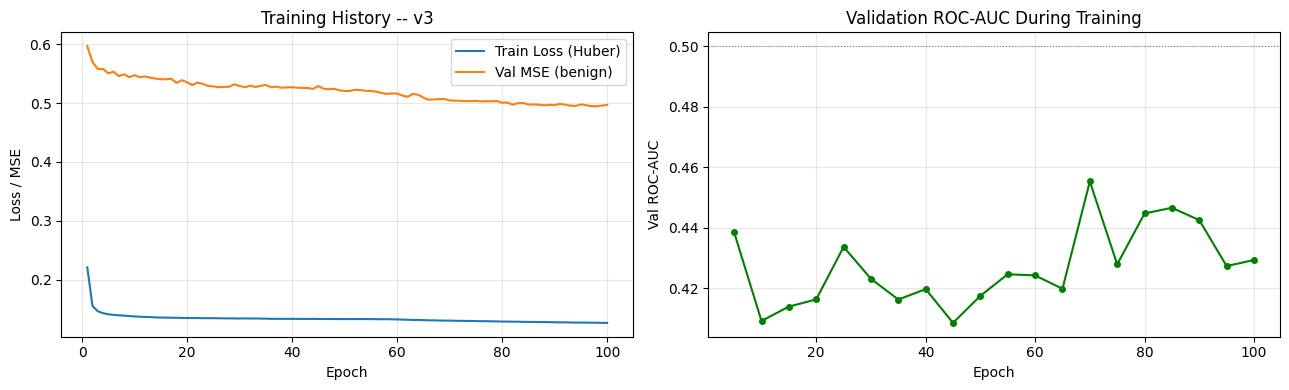

In [ ]:
import matplotlib.pyplot as plt

epochs_h = [r['epoch']          for r in history]
train_h  = [r['train_loss']     for r in history]
val_h    = [r['val_mse_benign'] for r in history]
auc_rows = [(r['epoch'], r['val_auc']) for r in history if 'val_auc' in r]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_h, train_h, label='Train Loss (Huber)', linewidth=1.5)
axes[0].plot(epochs_h, val_h,   label='Val MSE (benign)',   linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss / MSE')
axes[0].set_title('Training History -- v3')
axes[0].legend()
axes[0].grid(alpha=0.3)

if auc_rows:
    auc_e, auc_v = zip(*auc_rows)
    axes[1].plot(auc_e, auc_v, marker='o', markersize=4, linewidth=1.5, color='green')
    axes[1].axhline(0.5, linestyle=':', color='gray', linewidth=0.8)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Val ROC-AUC')
    axes[1].set_title('Validation ROC-AUC During Training')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_DIR / 'training_history_v3.png', dpi=150)
plt.show()

## 7. Per-Feature Variance Weighting

After training, compute the per-feature reconstruction standard deviation on benign validation windows. Features with low variance under normal traffic (stable features) contribute proportionally more to the anomaly score than naturally noisy features.

This reduces false positives from high-variance benign features dominating the score.

In [ ]:
# Compute per-feature reconstruction std on BENIGN validation windows.
# Used to normalize anomaly scores: low-variance features (stable under normal
# traffic) contribute more to the score than naturally noisy features.

X_val_benign = X_val[y_val == 0]
print(f'Computing per-feature reconstruction std from {len(X_val_benign)} benign val windows ...')

model.eval()
sq_errors = []
with torch.no_grad():
    for start in range(0, len(X_val_benign), SCORE_BATCH_SIZE):
        xb    = torch.from_numpy(X_val_benign[start:start + SCORE_BATCH_SIZE]).float().to(device)
        recon = model(xb)
        sq    = (recon - xb).pow(2).cpu().numpy()   # (B, T, F)
        sq_errors.append(sq)
        del xb, recon, sq

sq_errors = np.concatenate(sq_errors, axis=0)                   # (N, T, F)
feat_std  = sq_errors.reshape(-1, sq_errors.shape[2]).std(axis=0) + 1e-6  # (F,)
del sq_errors, X_val_benign
gc.collect()

print(f'feat_std: shape={feat_std.shape}')
print(f'  min={feat_std.min():.6f}  max={feat_std.max():.6f}  mean={feat_std.mean():.6f}')
print(f'  Features with low std (high signal weight): top 5 = {np.argsort(feat_std)[:5].tolist()}')
print(f'  Features with high std (low signal weight): top 5 = {np.argsort(feat_std)[-5:].tolist()}')

Computing per-feature reconstruction std from 961 benign val windows ...
feat_std: shape=(166,)
  min=0.035286  max=12.466615  mean=1.315179
  Features with low std (high signal weight): top 5 = [125, 32, 38, 11, 14]
  Features with high std (low signal weight): top 5 = [154, 148, 85, 145, 106]


## 8. Anomaly Scoring with Variance Weighting

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Score with per-feature variance weighting
s_val  = compute_scores(X_val,  feat_std=feat_std)
s_test = compute_scores(X_test, feat_std=feat_std)

print('Val  scores:')
print(f'  min={s_val.min():.6f}  max={s_val.max():.6f}  mean={s_val.mean():.6f}')
print('Test scores:')
print(f'  min={s_test.min():.6f}  max={s_test.max():.6f}  mean={s_test.mean():.6f}')

# Z-score normalization parameters (from BENIGN val scores)
s_benign_val = s_val[y_val == 0]
zscore_mu    = float(s_benign_val.mean())
zscore_sigma = float(s_benign_val.std())
print(f'Z-score params (benign val): mu={zscore_mu:.6f}  sigma={zscore_sigma:.6f}')

# Z-score normalized scores
s_val_z  = (s_val  - zscore_mu) / (zscore_sigma + 1e-9)
s_test_z = (s_test - zscore_mu) / (zscore_sigma + 1e-9)

val_auc  = roc_auc_score(y_val,  s_val)
test_auc = roc_auc_score(y_test, s_test)
print(f'ROC-AUC (raw scores)      -- val: {val_auc:.4f}  test: {test_auc:.4f}')
print(f'ROC-AUC (z-score, same)   -- val: {roc_auc_score(y_val, s_val_z):.4f}  '
      f'test: {roc_auc_score(y_test, s_test_z):.4f}')

# Score separation diagnostic
s_ben_val = s_val[y_val == 0]
s_att_val = s_val[y_val == 1]
print(f'Benign val  -- mean={s_ben_val.mean():.4f}  p95={np.percentile(s_ben_val, 95):.4f}')
print(f'Attack val  -- mean={s_att_val.mean():.4f}  p05={np.percentile(s_att_val,  5):.4f}')

Val  scores:
  min=0.094764  max=3.908171  mean=0.555482
Test scores:
  min=0.086160  max=3.771883  mean=0.555919
Z-score params (benign val): mu=0.570584  sigma=0.239432
ROC-AUC (raw scores)      -- val: 0.4073  test: 0.3969
ROC-AUC (z-score, same)   -- val: 0.4073  test: 0.3969
Benign val  -- mean=0.5706  p95=1.0768
Attack val  -- mean=0.5501  p05=0.1576


## 9. Multiple Thresholding Strategies

| Strategy | Use case |
|---|---|
| `youden_j` | Balanced TPR/FPR — standard baseline |
| `p95/p99_benign` | Guarantee low FPR on training distribution |
| `f1_optimal` | Max F1 on validation |
| `fbeta_0.5` | Precision-priority (FP costs 2× FN) — low alert fatigue |
| `fbeta_2.0` | Recall-priority (FN costs 2× FP) — miss nothing |
| `zscore_2.5/3.0` | Interpretable: flag if score > N sigma above benign mean |
| `precision_0.85` | Minimum 85% precision guarantee |

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve

PRECISION_TARGET = 0.85

def compute_thresholds(s_val, y_val, zscore_mu, zscore_sigma):
    thresholds = {}
    s_benign   = s_val[y_val == 0]

    # 1. Youden J  (baseline -- max TPR-FPR on ROC)
    fpr_r, tpr_r, thr_roc = roc_curve(y_val, s_val)
    j_idx = int(np.argmax(tpr_r[1:] - fpr_r[1:]))
    thresholds['youden_j'] = float(thr_roc[j_idx])

    # 2-3. Percentile on benign val
    thresholds['p95_benign'] = float(np.percentile(s_benign, 95))
    thresholds['p99_benign'] = float(np.percentile(s_benign, 99))

    # 4. F1-optimal
    prec, rec, thr_pr = precision_recall_curve(y_val, s_val)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    thresholds['f1_optimal'] = float(thr_pr[int(np.argmax(f1s))])

    # 5. F-beta 0.5  (precision-priority: FP costs 2x as much as FN)
    fb5 = (1 + 0.5**2) * prec[:-1] * rec[:-1] / (0.5**2 * prec[:-1] + rec[:-1] + 1e-9)
    thresholds['fbeta_0.5'] = float(thr_pr[int(np.argmax(fb5))])

    # 6. F-beta 2.0  (recall-priority: FN costs 2x as much as FP -- miss nothing)
    fb2 = (1 + 2.0**2) * prec[:-1] * rec[:-1] / (2.0**2 * prec[:-1] + rec[:-1] + 1e-9)
    thresholds['fbeta_2.0'] = float(thr_pr[int(np.argmax(fb2))])

    # 7-8. Z-score: threshold expressed as raw score value
    # "Flag if score is N sigma above benign mean" -- interpretable & scale-invariant
    thresholds['zscore_2.5'] = float(zscore_mu + 2.5 * zscore_sigma)
    thresholds['zscore_3.0'] = float(zscore_mu + 3.0 * zscore_sigma)

    # 9. Precision-target (lowest threshold where precision >= 0.85)
    valid = np.where(prec[:-1] >= PRECISION_TARGET)[0]
    thresholds['precision_0.85'] = (float(thr_pr[valid[-1]]) if len(valid) > 0
                                    else thresholds['p99_benign'])

    return thresholds


thresholds = compute_thresholds(s_val, y_val, zscore_mu, zscore_sigma)
print('Thresholds from validation set:')
for name, val in thresholds.items():
    print(f'  {name:18s}: {val:.6f}')

Thresholds from validation set:
  youden_j          : 0.765193
  p95_benign        : 1.076816
  p99_benign        : 1.388315
  f1_optimal        : 0.140358
  fbeta_0.5         : 0.140358
  fbeta_2.0         : 0.140358
  zscore_2.5        : 1.169166
  zscore_3.0        : 1.288882
  precision_0.85    : 3.908171


## 10. Complete Test Evaluation

In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, f1_score, matthews_corrcoef, balanced_accuracy_score,
)


def full_eval(s, y, threshold, label=''):
    y_pred = (s >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    roc_auc   = roc_auc_score(y, s)
    pr_auc    = average_precision_score(y, s)
    f1        = f1_score(y, y_pred, zero_division=0)
    mcc       = matthews_corrcoef(y, y_pred)
    bal_acc   = balanced_accuracy_score(y, y_pred)
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr       = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    result = dict(
        threshold=threshold, roc_auc=roc_auc, pr_auc=pr_auc,
        f1=f1, mcc=mcc, balanced_acc=bal_acc,
        precision=precision, recall=recall, fpr=fpr, fnr=fnr,
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
    )
    if label:
        print(f'=== {label} ===')
        print(f'  Threshold  : {threshold:.6f}')
        print(f'  ROC-AUC    : {roc_auc:.4f}   PR-AUC  : {pr_auc:.4f}')
        print(f'  F1         : {f1:.4f}   MCC     : {mcc:.4f}   BalAcc: {bal_acc:.4f}')
        print(f'  Precision  : {precision:.4f}   Recall  : {recall:.4f}')
        print(f'  FPR        : {fpr:.4f}   FNR     : {fnr:.4f}')
        print(f'  Confusion  : TP={tp} FP={fp} TN={tn} FN={fn}')
    return result


print('Test-set evaluation (all threshold strategies):')
print()
all_results = {}
for name, thr in thresholds.items():
    all_results[name] = full_eval(s_test, y_test, thr, label=name)

print()
print('=' * 85)
print(f'{"Strategy":<18} {"ROC-AUC":>8} {"PR-AUC":>8} {"F1":>7}'
      f' {"MCC":>7} {"BalAcc":>8} {"FPR":>7} {"FNR":>7}')
print('-' * 85)
for name, r in all_results.items():
    print(f'{name:<18} {r["roc_auc"]:>8.4f} {r["pr_auc"]:>8.4f}'
          f' {r["f1"]:>7.4f} {r["mcc"]:>7.4f} {r["balanced_acc"]:>8.4f}'
          f' {r["fpr"]:>7.4f} {r["fnr"]:>7.4f}')
print('=' * 85)

Test-set evaluation (all threshold strategies):

=== youden_j ===
  Threshold  : 0.765193
  ROC-AUC    : 0.3969   PR-AUC  : 0.7084
  F1         : 0.3869   MCC     : 0.1553   BalAcc: 0.5719
  Precision  : 0.8690   Recall  : 0.2489
  FPR        : 0.1050   FNR     : 0.7511
  Confusion  : TP=670 FP=101 TN=861 FN=2022
=== p95_benign ===
  Threshold  : 1.076816
  ROC-AUC    : 0.3969   PR-AUC  : 0.7084
  F1         : 0.0216   MCC     : -0.1456   BalAcc: 0.4744
  Precision  : 0.3333   Recall  : 0.0111
  FPR        : 0.0624   FNR     : 0.9889
  Confusion  : TP=30 FP=60 TN=902 FN=2662
=== p99_benign ===
  Threshold  : 1.388315
  ROC-AUC    : 0.3969   PR-AUC  : 0.7084
  F1         : 0.0169   MCC     : -0.0086   BalAcc: 0.4991
  Precision  : 0.6970   Recall  : 0.0085
  FPR        : 0.0104   FNR     : 0.9915
  Confusion  : TP=23 FP=10 TN=952 FN=2669
=== f1_optimal ===
  Threshold  : 0.140358
  ROC-AUC    : 0.3969   PR-AUC  : 0.7084
  F1         : 0.8497   MCC     : 0.0852   BalAcc: 0.5055
  Precisi

## 11. Score Distribution & ROC/PR Curves

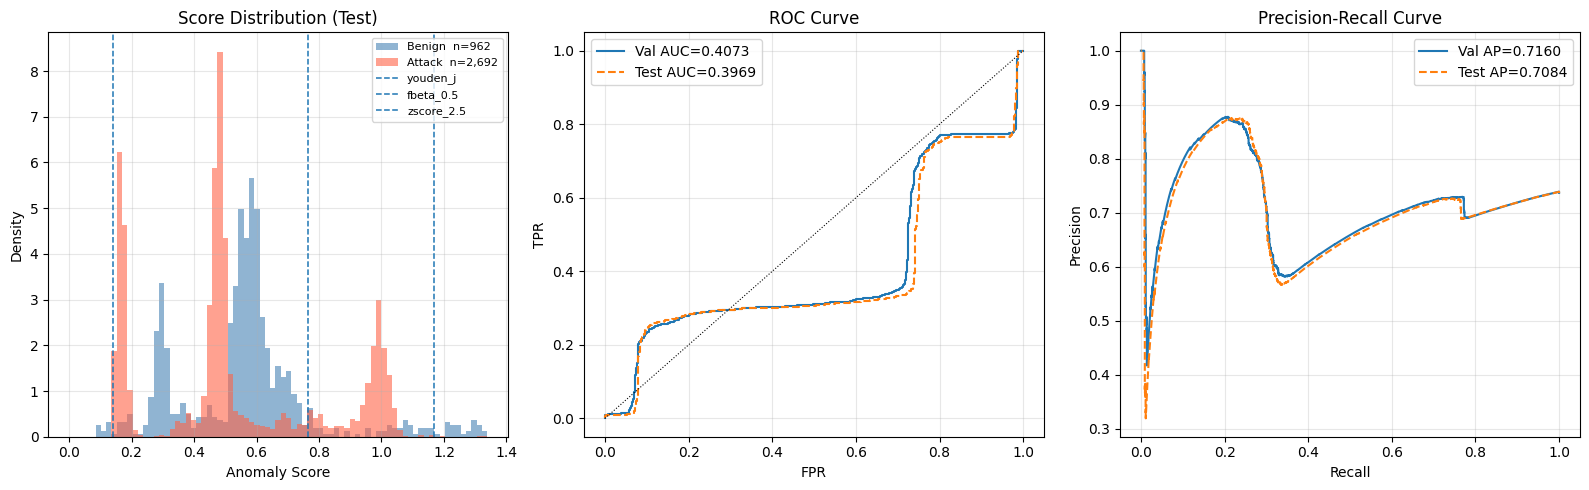

Plots saved.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Score distribution (test set)
ax   = axes[0]
s_bn = s_test[y_test == 0]
s_at = s_test[y_test == 1]
hi   = np.percentile(s_test, 99)
bins = np.linspace(0, hi, 80)
ax.hist(s_bn, bins=bins, alpha=0.6, density=True,
        color='steelblue', label=f'Benign  n={len(s_bn):,}')
ax.hist(s_at, bins=bins, alpha=0.6, density=True,
        color='tomato',    label=f'Attack  n={len(s_at):,}')
for name in ('youden_j', 'fbeta_0.5', 'zscore_2.5'):
    if name in thresholds:
        ax.axvline(thresholds[name], linestyle='--', linewidth=1.1, label=name)
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution (Test)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. ROC curve
ax = axes[1]
for split, s, y, ls in [('Val', s_val, y_val, '-'), ('Test', s_test, y_test, '--')]:
    fp_r, tp_r, _ = roc_curve(y, s)
    auc = roc_auc_score(y, s)
    ax.plot(fp_r, tp_r, linestyle=ls, label=f'{split} AUC={auc:.4f}')
ax.plot([0, 1], [0, 1], 'k:', linewidth=0.8)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(alpha=0.3)

# 3. Precision-Recall curve
ax = axes[2]
for split, s, y, ls in [('Val', s_val, y_val, '-'), ('Test', s_test, y_test, '--')]:
    pr, rc, _ = precision_recall_curve(y, s)
    ap = average_precision_score(y, s)
    ax.plot(rc, pr, linestyle=ls, label=f'{split} AP={ap:.4f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_DIR / 'evaluation_plots_v3.png', dpi=150)
plt.show()
print('Plots saved.')

## 12. Optuna HPO

Search space includes `huber_delta` and `bottleneck_dim` in {8, 16, 32}.
Objective: val ROC-AUC (unweighted scores — feat_std not available inside HPO trials).

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def hpo_objective(trial: optuna.Trial) -> float:
    d_model        = trial.suggest_categorical('d_model',        [32, 64, 128])
    bottleneck_dim = trial.suggest_categorical('bottleneck_dim', [8, 16, 32])
    num_enc_layers = trial.suggest_int('num_enc_layers', 1, 3)
    num_dec_layers = trial.suggest_int('num_dec_layers', 1, 2)
    dim_ff         = trial.suggest_categorical('dim_ff',         [96, 192, 256])
    dropout        = trial.suggest_float('dropout',    0.05, 0.30)
    lr             = trial.suggest_float('lr',         1e-4, 5e-3, log=True)
    noise_std      = trial.suggest_float('noise_std',  0.01, 0.10)
    huber_delta    = trial.suggest_float('huber_delta', 0.5, 2.0)

    if bottleneck_dim >= d_model:
        raise optuna.exceptions.TrialPruned()

    nhead = 4 if d_model % 4 == 0 else 2
    m = build_model(
        n_features=n_features, d_model=d_model, nhead=nhead,
        num_enc_layers=num_enc_layers, num_dec_layers=num_dec_layers,
        dim_ff=dim_ff, dropout=dropout, bottleneck_dim=bottleneck_dim,
    )
    loader = DataLoader(
        TensorDataset(X_train_t), batch_size=BATCH_SIZE,
        shuffle=True, drop_last=False, pin_memory=False, num_workers=0,
    )
    opt_m   = optim.AdamW(m.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    xv_b    = X_val_t[y_val == 0].to(device)
    best_v, no_imp = float('inf'), 0

    for epoch in range(1, HPO_MAX_EPOCH + 1):
        m.train()
        for (xb,) in loader:
            xb = xb.to(device)
            opt_m.zero_grad(set_to_none=True)
            loss = F.huber_loss(m(add_noise(xb, noise_std)), xb, delta=huber_delta)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt_m.step()

        m.eval()
        with torch.no_grad():
            v_mse = float(F.mse_loss(m(xv_b), xv_b).item())

        trial.report(v_mse, epoch)
        if trial.should_prune():
            del m, opt_m, xv_b, loader
            gc.collect()
            raise optuna.exceptions.TrialPruned()

        if v_mse < best_v - 1e-6:
            best_v, no_imp = v_mse, 0
        else:
            no_imp += 1
        if no_imp >= HPO_PATIENCE:
            break

    # Score val and compute ROC-AUC (unweighted -- feat_std not available in HPO)
    s_chunks = []
    m.eval()
    with torch.no_grad():
        for start in range(0, len(X_val), SCORE_BATCH_SIZE):
            xb    = torch.from_numpy(X_val[start:start + SCORE_BATCH_SIZE]).float().to(device)
            recon = m(xb)
            err   = (recon - xb).pow(2)
            s_chunks.append(
                (SCORE_MEAN_W * err.mean(dim=(1, 2)) +
                 SCORE_MAX_W  * err.mean(dim=2).amax(dim=1)).cpu().numpy()
            )
            del xb, recon, err
    s_v = np.concatenate(s_chunks)

    del m, opt_m, xv_b, loader, s_chunks
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    try:
        return float(roc_auc_score(y_val, s_v))
    except Exception:
        return 0.5


study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    study_name='mdc_v3_hpo',
)
print(f'Starting Optuna HPO: {N_TRIALS} trials, {HPO_MAX_EPOCH} epochs each ...')
study.optimize(hpo_objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_trial
print(f'Best Val ROC-AUC: {best.value:.4f}')
print(f'Best params     : {best.params}')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Starting Optuna HPO: 15 trials, 30 epochs each ...


  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_2870/4276833471.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_2870/4276833471.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_2870/4276833471.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_2870/4276833471.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_2870/4276833471.py:54: UserWarning: enabl

Best Val ROC-AUC: 0.4844
Best params     : {'d_model': 64, 'bottleneck_dim': 32, 'num_enc_layers': 1, 'num_dec_layers': 2, 'dim_ff': 256, 'dropout': 0.05092221907023925, 'lr': 0.0028115333610756457, 'noise_std': 0.010470407872362225, 'huber_delta': 1.6669993221877313}


## 13. Retrain with Best HPO Params

In [ ]:
print('Retraining with best HPO params ...')
bp         = best.params
nhead_best = 4 if bp['d_model'] % 4 == 0 else 2

model_best = build_model(
    n_features=n_features,
    d_model=bp['d_model'],         nhead=nhead_best,
    num_enc_layers=bp['num_enc_layers'],
    num_dec_layers=bp['num_dec_layers'],
    dim_ff=bp['dim_ff'],           dropout=bp['dropout'],
    bottleneck_dim=bp['bottleneck_dim'],
)
loader_best = DataLoader(
    TensorDataset(X_train_t), batch_size=BATCH_SIZE,
    shuffle=True, drop_last=False, pin_memory=False, num_workers=0,
)
_, history_best = train_model(
    model_best, loader_best, X_val_t, y_val,
    lr=bp['lr'],
    noise_std=bp['noise_std'],
    huber_delta=bp.get('huber_delta', HUBER_DELTA),
    use_denoising=True,
    verbose=True,
)
del loader_best
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Re-compute feat_std for the best model
model = model_best
X_val_benign_hpo = X_val[y_val == 0]
sq_err_hpo       = []
model.eval()
with torch.no_grad():
    for start in range(0, len(X_val_benign_hpo), SCORE_BATCH_SIZE):
        xb    = torch.from_numpy(X_val_benign_hpo[start:start + SCORE_BATCH_SIZE]).float().to(device)
        recon = model(xb)
        sq_err_hpo.append((recon - xb).pow(2).cpu().numpy())
        del xb, recon
sq_err_hpo = np.concatenate(sq_err_hpo, axis=0)
feat_std_best = sq_err_hpo.reshape(-1, sq_err_hpo.shape[2]).std(axis=0) + 1e-6
del sq_err_hpo, X_val_benign_hpo
gc.collect()

s_val_best  = compute_scores(X_val,  feat_std=feat_std_best)
s_test_best = compute_scores(X_test, feat_std=feat_std_best)

zscore_mu_b    = float(s_val_best[y_val == 0].mean())
zscore_sigma_b = float(s_val_best[y_val == 0].std())
thresholds_best = compute_thresholds(s_val_best, y_val, zscore_mu_b, zscore_sigma_b)

print()
print('=== HPO Best Model -- Test Evaluation ===')
print(f'{"Strategy":<18} {"ROC-AUC":>8} {"PR-AUC":>8} {"F1":>7}'
      f' {"MCC":>7} {"BalAcc":>8} {"FPR":>7} {"FNR":>7}')
print('-' * 85)
for name, thr in thresholds_best.items():
    r = full_eval(s_test_best, y_test, thr)
    print(f'{name:<18} {r["roc_auc"]:>8.4f} {r["pr_auc"]:>8.4f}'
          f' {r["f1"]:>7.4f} {r["mcc"]:>7.4f} {r["balanced_acc"]:>8.4f}'
          f' {r["fpr"]:>7.4f} {r["fnr"]:>7.4f}')
print('=' * 85)

## 14. Save Final Model & Artifacts

In [ ]:
from datetime import datetime, timezone

torch.save({
    'model'      : model_best.state_dict(),
    'hpo_params' : bp,
    'val_roc_auc': best.value,
    'feat_std'   : feat_std_best,
    'zscore_mu'  : zscore_mu_b,
    'zscore_sigma': zscore_sigma_b,
    'config': {
        'T': T, 'n_features': n_features,
        'd_model'        : bp['d_model'],
        'bottleneck_dim' : bp['bottleneck_dim'],
        'nhead'          : nhead_best,
        'num_enc_layers' : bp['num_enc_layers'],
        'num_dec_layers' : bp['num_dec_layers'],
        'dim_ff'         : bp['dim_ff'],
        'dropout'        : bp['dropout'],
    },
}, RUN_DIR / 'checkpoint_v3_best.pt')

np.savez_compressed(
    RUN_DIR / 'scores_v3.npz',
    s_val=s_val_best, s_test=s_test_best,
    y_val=y_val, y_test=y_test,
    feat_std=feat_std_best,
)

thr_report = thresholds_best['youden_j']
final      = full_eval(s_test_best, y_test, thr_report)

summary = {
    'created_at'       : datetime.now(timezone.utc).isoformat(),
    'version'          : 'v3',
    'hpo_params'       : bp,
    'thresholds'       : thresholds_best,
    'default_threshold': thr_report,
    'test_roc_auc'     : final['roc_auc'],
    'test_pr_auc'      : final['pr_auc'],
    'test_f1'          : final['f1'],
    'test_mcc'         : final['mcc'],
    'test_balanced_acc': final['balanced_acc'],
    'test_precision'   : final['precision'],
    'test_recall'      : final['recall'],
    'test_fpr'         : final['fpr'],
    'test_fnr'         : final['fnr'],
    'confusion'        : {'tp': final['tp'], 'fp': final['fp'],
                          'tn': final['tn'], 'fn': final['fn']},
    'train_shapes'     : {
        'X_train': list(X_train_t.shape),
        'X_val'  : list(X_val.shape),
        'X_test' : list(X_test.shape),
    },
    'zscore_mu'   : zscore_mu_b,
    'zscore_sigma': zscore_sigma_b,
}
(RUN_DIR / 'metrics_v3.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('All artifacts saved to:', RUN_DIR)
print(json.dumps({k: round(v, 4) for k, v in {
    'test_roc_auc'     : final['roc_auc'],
    'test_pr_auc'      : final['pr_auc'],
    'test_f1'          : final['f1'],
    'test_mcc'         : final['mcc'],
    'test_balanced_acc': final['balanced_acc'],
    'test_fpr'         : final['fpr'],
    'test_fnr'         : final['fnr'],
}.items()}, indent=2))

## 15. Fallback: Default-Config Model (No HPO)

In [ ]:
# Reload and evaluate the default-config model (no HPO)
# Useful if HPO was skipped or timed out
ckpt    = torch.load(RUN_DIR / 'checkpoint_v3.pt', map_location=device)
cfg     = ckpt['config']
m_def   = build_model(
    n_features=cfg['n_features'],     d_model=cfg['d_model'],
    bottleneck_dim=cfg['bottleneck_dim'],
    num_enc_layers=cfg['num_enc_layers'],
    num_dec_layers=cfg['num_dec_layers'],
    dim_ff=cfg['dim_ff'],             dropout=cfg['dropout'],
)
m_def.load_state_dict(ckpt['model'])
m_def.eval()
del ckpt
gc.collect()

_prev_model = model
model       = m_def

# Compute feat_std for default model
X_vb_def   = X_val[y_val == 0]
sq_def     = []
with torch.no_grad():
    for start in range(0, len(X_vb_def), SCORE_BATCH_SIZE):
        xb    = torch.from_numpy(X_vb_def[start:start + SCORE_BATCH_SIZE]).float().to(device)
        recon = model(xb)
        sq_def.append((recon - xb).pow(2).cpu().numpy())
        del xb, recon
sq_def       = np.concatenate(sq_def, axis=0)
feat_std_def = sq_def.reshape(-1, sq_def.shape[2]).std(axis=0) + 1e-6
del sq_def, X_vb_def
gc.collect()

s_val_def    = compute_scores(X_val,  feat_std=feat_std_def)
s_test_def   = compute_scores(X_test, feat_std=feat_std_def)
zm_d         = float(s_val_def[y_val == 0].mean())
zs_d         = float(s_val_def[y_val == 0].std())
thr_def      = compute_thresholds(s_val_def, y_val, zm_d, zs_d)
r_def        = full_eval(s_test_def, y_test, thr_def['youden_j'], label='default/youden_j')

model = _prev_model
del m_def, _prev_model
gc.collect()
print(f'Default model -- ROC-AUC: {r_def["roc_auc"]:.4f}  F1: {r_def["f1"]:.4f}')